This Jupyter Notebook is part of a **collection of scripts curated by Tarlan Ahadli** for the **2025 Spring Semester**, based on **projects provided by Prof. Hajder Levente**. These scripts cover a range of computational topics, including **computer vision, image processing, numerical computing, and matrix transformations**, serving as educational resources for academic use.

### **Usage Restrictions**
This material is **strictly for academic and educational purposes**.  
**Commercial use is prohibited.**

For any **issues, suggestions, or inquiries**, please contact:  
📧 **tarlanahad@gmail.com**

# **RANSAC for Line Fitting**
In this notebook, we'll explore the RANSAC (Random Sample Consensus) algorithm for robust line fitting. We'll generate synthetic data with a mixture of **inliers** and **outliers**, then apply the RANSAC procedure to estimate a line that best fits the inliers while rejecting the outliers.

## **Table of Contents**
1. Overview
2. Synthetic Data Generation
3. RANSAC Algorithm
4. Implementation
5. Results
6. Conclusion

---


## 1. Overview
**RANSAC** stands for **Random Sample Consensus**. It is a popular algorithm to robustly fit a model (like a line or plane) when the data contains a large number of outliers.

**Key Steps**:
1. Randomly select a small subset of data to form a model.
2. Determine how many points from the entire dataset fit the model (inliers).
3. Update the best model if the new one has more inliers.
4. Adaptively update the number of iterations needed based on the ratio of inliers found.
5. Refit the final line using all inliers of the best model.


## 2. Synthetic Data Generation
For this demonstration, we'll generate a 2D dataset that is partly on a line (inliers) and partly random (outliers).


## Mathematical Explanation of `generate_data(N, p, direction, inlier_ratio)`

This function generates a set of $ N $ two-dimensional points, consisting of:

- **Inlier Points** that lie roughly along a line passing through a reference point $ \mathscr{p} $ in the direction of $ \mathscr{d} $.
- **Outlier Points** scattered randomly within a bounding rectangle $ [0, \text{WIDTH}] \times [0, \text{HEIGHT}] $.

### Step-by-Step Mathematical Breakdown

### 1. Normalize Direction Vector
We normalize the direction vector $ \mathscr{d} $ as:

$$
\mathbf{d} \leftarrow \frac{\mathscr{d}}{\|\mathscr{d}\|}
$$

ensuring that $ \|\mathbf{d}\| = 1 $.

### 2. Partition $ N $ into Inliers and Outliers
Given $\text{inlier_ratio}$, we compute:

$$
\begin{align}
N_{\text{inlier}} &= \lfloor N \times \text{inlier_ratio} \rfloor \\
N_{\text{outlier}} &= N - N_{\text{inlier}}
\end{align}
$$

### 3. Generate Inliers Along a Line
- Define $ \mathscr{p} $ as the base point.
- Select $ t \sim \text{Uniform}(-\frac{\text{diag}}{2}, \frac{\text{diag}}{2}) $, where:

  $$
  \text{diag} = \sqrt{\text{WIDTH}^2 + \text{HEIGHT}^2}.
  $$

- Compute each inlier point:

  $$
  \mathscr{q} = \mathscr{p} + t \mathscr{d}.
  $$

- Add **Gaussian noise** $ \mathscr{N}(0,10) $ to both coordinates.


  $$
  \begin{align}
  \mathscr{q}[0] &\leftarrow \mathscr{q}[0] + \mathscr{N}(0,10) \\
  \mathscr{q}[1] &\leftarrow \mathscr{q}[1] + \mathscr{N}(0,10).
  \end{align}
  $$

### 4. Generate Outliers
For each of the $ N_{\text{outlier}} $ points, sample randomly:

$$
\begin{align}
x &\sim \text{Uniform}(0, \text{WIDTH}) \\
y &\sim \text{Uniform}(0, \text{HEIGHT}).
\end{align}
$$

### 5. Return Combined Array
Finally, we combine both inlier and outlier sets into a single NumPy array $ \mathbb{R}^{N \times 2} $.

### Purpose
This approach simulates a **robust line model** with a specified inlier ratio, useful for testing RANSAC or other robust fitting algorithms under controlled conditions.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

def init_random(seed=None):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

def generate_data(N, p, direction, inlier_ratio=0.5):
    WIDTH, HEIGHT = 640, 480
    p = np.array(p, dtype=float)
    direction = np.array(direction, dtype=float)
    direction /= np.linalg.norm(direction)

    N_inlier = int(N * inlier_ratio)
    N_outlier = N - N_inlier

    points = []

    diag = np.sqrt(WIDTH**2 + HEIGHT**2)
    for _ in range(N_inlier):
        t = (random.random() * diag) - diag / 2.0
        q = p + t * direction
        q[0] += np.random.normal(0.0, 10.0)
        q[1] += np.random.normal(0.0, 10.0)
        points.append(q)

    for _ in range(N_outlier):
        points.append((random.random() * WIDTH, random.random() * HEIGHT))

    return np.array(points, dtype=float)


In [2]:
init_random(seed=0)

N = 1000
p = (240.0, 320.0)
alpha = random.random() * 2.0 * np.pi
dir_ = (np.cos(alpha), np.sin(alpha))
points = generate_data(N, p, dir_, inlier_ratio=0.5)

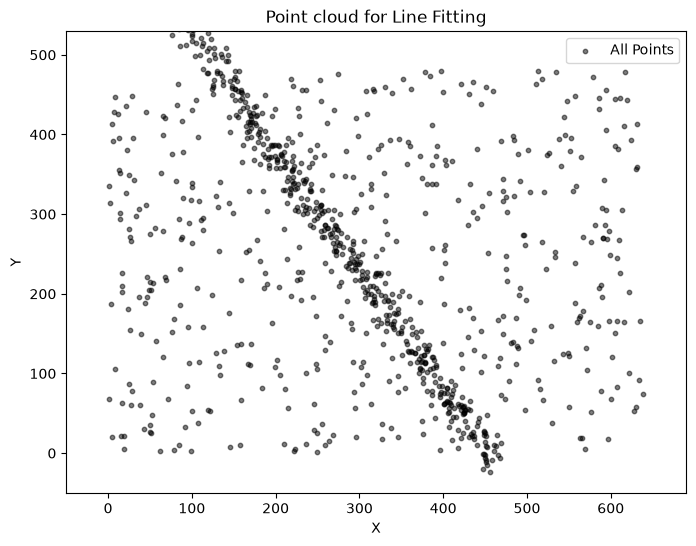

In [3]:
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(points[:,0], points[:,1], s=10, c='k', alpha=0.5, label='All Points')


ax.set_xlim([-50, 690])
ax.set_ylim([-50, 530])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Point cloud for Line Fitting')
ax.legend()
plt.show()


## 3. RANSAC Algorithm
To robustly fit a line, we perform these steps repeatedly:

1. **Random Sampling**: Pick two distinct points from the dataset.
2. **Model Fitting**: Estimate a line from these two points.
3. **Distance Calculation**: Compute the perpendicular distance to the line.
4. **Counting Inliers**: Determine inliers based on a threshold.
5. **Best Model Update**: Keep the best-fitting model.
6. **Adaptive Iteration**: Adjust iterations based on inlier ratio.
7. **Final Refinement**: Solve an over-determined least-squares system using all inliers of the best model.


## Fit a line using two points: $y = mx + b$

The line is stored as `(m, b)`, where `m` is the slope and `b` is the intercept.
For two points $(x_1,y_1)$ and $(x_2,y_2)$:

$$m = \frac{y_2-y_1}{x_2-x_1}, \qquad b = y_1-mx_1.$$

If the x coordinates are equal (or almost equal), we skip the pair to avoid division by zero.
The explicit form cannot represent vertical lines; this example fits a nonvertical line.


In [4]:
import math

def fit_line_two_points(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    if abs(x2 - x1) < 1e-8:
        return None
    m = (y2 - y1) / (x2 - x1)
    b = y1 - m * x1
    return m, b


## Perpendicular distance to $y = mx + b$

For a point $(x,y)$, the perpendicular distance is:

$$d = \frac{|mx+b-y|}{\sqrt{m^2+1}}.$$

We keep the perpendicular distance used by the original RANSAC algorithm.
Dividing by $\sqrt{m^2+1}$ is necessary: $|mx+b-y|$ alone is the vertical error.
A point is an inlier if its perpendicular distance is smaller than `sigma`.


In [5]:
def distance_point_line(line_params, point):
    m, b = line_params
    x, y = point
    return abs(m * x + b - y) / math.sqrt(m**2 + 1)


## Mathematical Explanation of `iteration_number(confidence, sample_size, inliers, N)`

This function computes the **number of RANSAC iterations** required to ensure, with a given confidence level, that at least one randomly selected subset consists entirely of inliers.

### Step-by-Step Mathematical Breakdown

### 1. Key Terms and Definitions
- **Inlier Ratio** \( w \): The fraction of points that are inliers.
- **Sample Size** \( s \): The minimum number of points needed to estimate the model.
- **Confidence** \( p \): The probability that at least one sample contains only inliers.

The probability of picking an inlier at random is:

$$
 w = \frac{\text{inliers}}{N}.
$$

If ( inliers = 0 ), then \( w = 0 \), meaning RANSAC cannot reliably find a correct model. In this case, the function returns \( $\infty$ \) (indicating an unbounded number of iterations might be required).

### 2. Probability of a Good Sample
The probability that a randomly chosen sample of size \( s \) consists **only** of inliers is:

$$
 w^s.
$$

### 3. Probability of All Bad Samples
If we run \( k \) iterations, the probability that **none** of these \( k \) samples contain only inliers is:

$$
 (1 - w^s)^k.
$$

### 4. Confidence Constraint
To ensure a confidence level \( p \), we require:

$$
 (1 - w^s)^k \leq 1 - p.
$$

### 5. Solving for \( k \)
Taking the natural logarithm of both sides:

$$
 k \ln(1 - w^s) \leq \ln(1 - p).
$$

Thus:

$$
 k \geq \frac{\ln(1 - p)}{\ln(1 - w^s)}.
$$

Since RANSAC requires an integer number of iterations, we take the **ceiling**:

$$
 k = \left\lceil \frac{\ln(1 - p)}{\ln(1 - w^s)} \right\rceil.
$$

### 6. Return Value
- If `inliers == 0`, we return \( $\infty$ \) since no inlier-based model can be drawn.
- If the denominator \( $\ln(\dots)$ \) is zero or extremely small, we also return \( $\infty$ \).
- Otherwise, we return the **ceiling** of the above fraction, indicating the required iterations to reach the given confidence level.


If all points are inliers, return 1 directly to avoid taking the logarithm of zero.


In [6]:
def iteration_number(confidence, sample_size, inliers, N):
    if inliers == 0:
        return float('inf')
    if inliers == N:
        return 1
    ratio = inliers / float(N)
    top = math.log(1.0 - confidence)
    bottom = math.log(1.0 - ratio**sample_size)
    return math.ceil(top / bottom) if bottom != 0 else float('inf')


In [7]:
def fit_line_least_squares(inliers):
    x = inliers[:, 0]
    y = inliers[:, 1]
    # Each row represents the equation m*x + b = y.
    A = np.column_stack((x, np.ones(len(x))))
    m, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return m, b


def ransac_line(points, max_iterations=2000, sigma=10.0, confidence=0.95):
    if len(points) < 2:
        raise ValueError("At least two points are needed.")
    best_line = None
    best_inliers_list = []
    iteration = 0

    # A while loop allows the iteration limit to change during RANSAC.
    while iteration < max_iterations:
        iteration += 1
        idx1, idx2 = np.random.choice(len(points), 2, replace=False)
        line_params = fit_line_two_points(points[idx1], points[idx2])
        if line_params is None:
            continue

        inliers = [pt for pt in points
                   if distance_point_line(line_params, pt) < sigma]

        if len(inliers) > len(best_inliers_list):
            best_line = line_params
            best_inliers_list = inliers
            needed = iteration_number(confidence, 2, len(inliers), len(points))
            max_iterations = min(max_iterations, needed)

    if best_line is None:
        raise ValueError("No nonvertical line found. Check the points and sigma.")

    # Final over-determined fit: use ALL inliers of the best RANSAC model.
    best_inliers = np.array(best_inliers_list)
    best_line = fit_line_least_squares(best_inliers)
    return best_line, best_inliers


## 4. Implementation: final over-determined solution

After RANSAC selects its best inlier set, we fit $y = mx+b$ using **all** of those points.
For $n$ inliers we solve:

$$
\begin{bmatrix}
x_1 & 1 \\
x_2 & 1 \\
\vdots & \vdots \\
x_n & 1
\end{bmatrix}
\begin{bmatrix}m\\b\end{bmatrix}
\approx
\begin{bmatrix}y_1\\y_2\\\vdots\\y_n\end{bmatrix}.
$$

There are two unknowns and more than two equations when $n>2$, so this is an
**over-determined system**. `np.linalg.lstsq` finds the slope and intercept that
minimize the sum of squared vertical errors:

$$\sum_{i=1}^{n}(y_i-(mx_i+b))^2.$$

RANSAC uses perpendicular distances to select inliers; this final ordinary
least-squares fit minimizes vertical errors. These are different criteria.
The returned inliers are the consensus set selected **before** the final fit;
we keep this set fixed for the refinement and the plot.


In [8]:
best_line, inliers = ransac_line(points)
m, b = best_line
print(f"Refined line: y = {m:.3f}x + ({b:.3f})")
print(f"Number of RANSAC inliers: {len(inliers)} out of {len(points)}")
print(f"Least-squares system: {len(inliers)} equations, 2 unknowns")


Refined line: y = -1.502x + (679.028)
Number of RANSAC inliers: 354 out of 1000
Least-squares system: 354 equations, 2 unknowns


## 5. Results
We'll visualize the **inlier** and **outlier** points, and also draw the **true line** and **RANSAC-fitted line**.


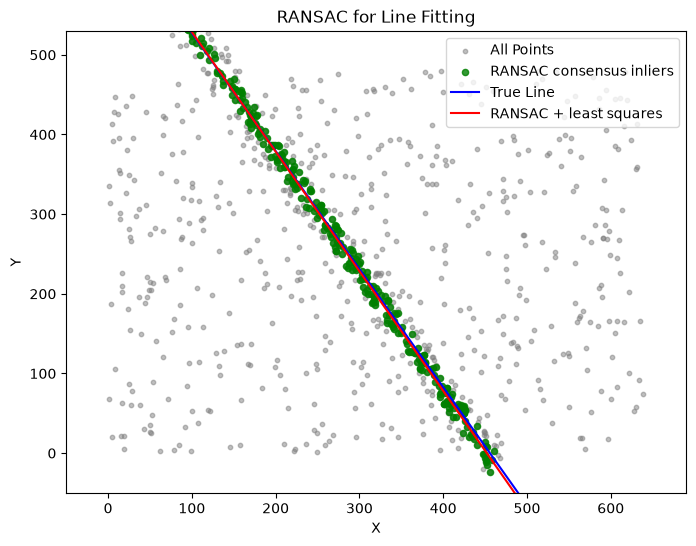

In [9]:
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(points[:,0], points[:,1], s=10, c='gray', alpha=0.5, label='All Points')
ax.scatter(inliers[:,0], inliers[:,1], s=20, c='green', alpha=0.8, label='RANSAC consensus inliers')

p1 = (p[0] - 1000*dir_[0], p[1] - 1000*dir_[1])
p2 = (p[0] + 1000*dir_[0], p[1] + 1000*dir_[1])
ax.plot([p1[0], p2[0]], [p1[1], p2[1]], c='blue', label='True Line')

m, b = best_line
x_vals = np.linspace(0, 640, 2)
y_vals = m * x_vals + b
ax.plot(x_vals, y_vals, c='red', label='RANSAC + least squares')

ax.set_xlim([-50, 690])
ax.set_ylim([-50, 530])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('RANSAC for Line Fitting')
ax.legend()
plt.show()
